# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [3]:
import pandas as pd
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from typing import List, Tuple, Dict


In [4]:
# Загрузка русской языковой модели spaCy
nlp = spacy.load("ru_core_news_sm")

In [2]:
# Для русского языка — Natasha
try:
    from natasha import MorphVocab, Doc, SentenceTokenizer
    morph_vocab = MorphVocab()
    use_natasha = True
except ImportError:
    use_natasha = False



# Для русского языка — SpaCy
try:
    nlp_ru = spacy.load("ru_core_news_sm")
    use_spacy_ru = True
except OSError:
    use_spacy_ru = False
    print("Модель ru_core_news_sm не найдена. Установите: python -m spacy download ru_core_news_sm")

Начало обработки...
Найдено 359 сочетаний подлежащее-сказуемое
Уникальных сочетаний: 354


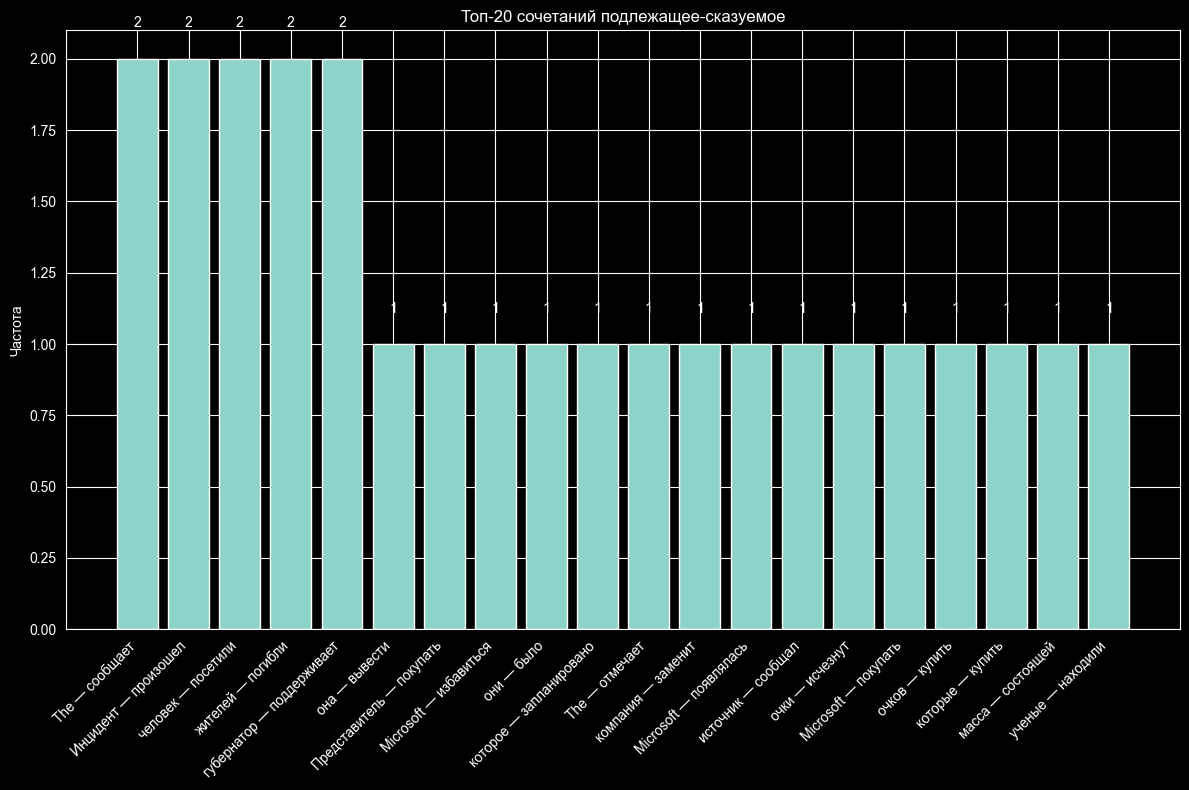

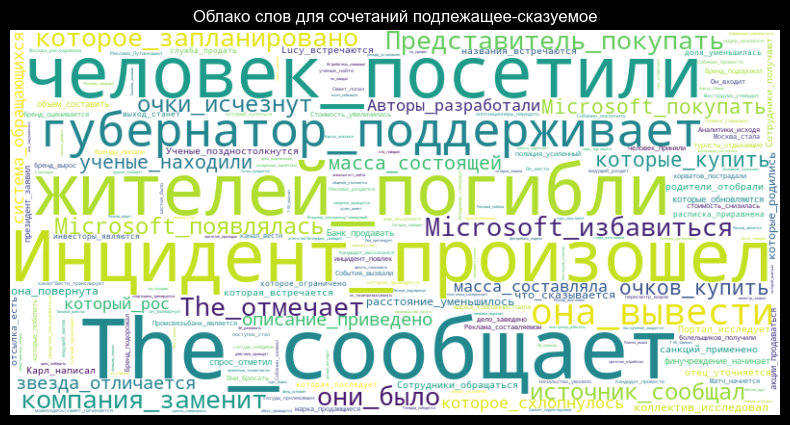

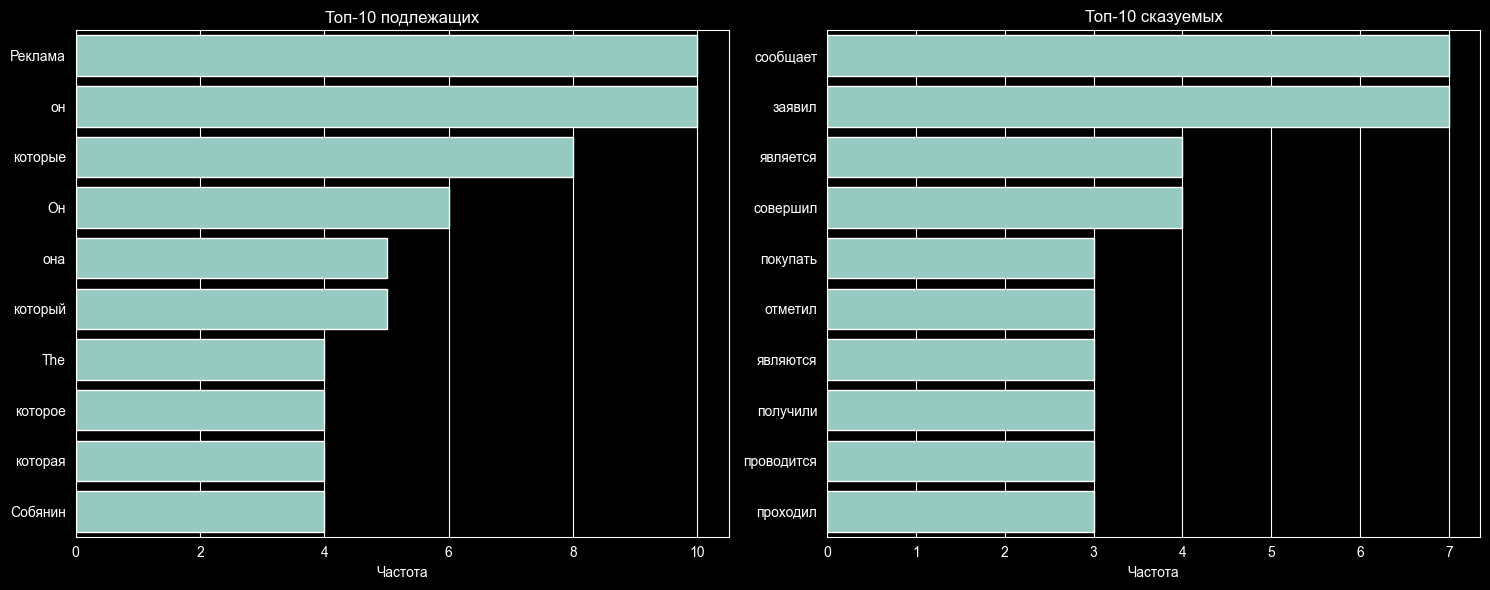

Результаты сохранены в results_analysis.csv


In [5]:
# Загрузка данных
df = pd.read_csv('articles.csv')

def detect_language(text):
    """Определяет язык текста (русский/английский)"""
    if any(c in 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя' for c in text.lower()):
        return 'ru'
    else:
        return 'en'

def extract_subject_predicate_natasha(text):
    """Извлекает подлежащее и сказуемое с помощью Natasha (русский язык)"""
    doc = Doc(text)
    doc.segment(SentenceTokenizer())
    doc.tag_morph(morph_vocab)

    pairs = []
    for sent in doc.sents:
        sent.parse_syntax()
        for token in sent.tokens:
            if token.pos == 'VERB' and token.head_id:
                head_token = sent.tokens[token.head_id - 1]
                if head_token.pos == 'NOUN' or head_token.pos == 'PROPN':
                    pairs.append((head_token.text, token.text))
    return pairs

def extract_subject_predicate_spacy(text, nlp):
    """Извлекает подлежащее и сказуемое с помощью SpaCy"""
    doc = nlp(text)
    pairs = []

    for sent in doc.sents:
        subject = None
        predicate = None

        for token in sent:
            if "nsubj" in token.dep_:
                subject = token.text
            elif token.pos_ == "VERB":
                predicate = token.text

        if subject and predicate:
            pairs.append((subject, predicate))

    return pairs

def process_text(text):
    """Основная функция обработки текста"""
    lang = detect_language(text)

    if lang == 'ru':
        if use_natasha:
            return extract_subject_predicate_natasha(text)
        elif use_spacy_ru:
            return extract_subject_predicate_spacy(text, nlp_ru)
        else:
            raise Exception("Нет доступных инструментов для русского языка")


def build_cooccurrence_pairs(df):
    """Построение зависимостей совместных употреблений"""
    all_pairs = []

    for _, row in df.iterrows():
        text = row['Text']
        if pd.notna(text):  # Проверка на NaN
            pairs = process_text(text)
            all_pairs.extend(pairs)

    return all_pairs

def analyze_frequencies(pairs):
    """Подсчёт частот с помощью Counter"""
    counter = Counter(pairs)
    return counter

def visualize_frequencies(counter, top_n=20):
    """Визуализация частот сочетаний"""
    top_pairs = counter.most_common(top_n)
    subjects, predicates = zip(*[pair for pair, _ in top_pairs])
    counts = [count for _, count in top_pairs]

    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.bar(range(len(top_pairs)), counts)
    ax.set_xticks(range(len(top_pairs)))
    ax.set_xticklabels([f"{s} — {p}" for s, p in zip(subjects, predicates)], rotation=45, ha='right')
    ax.set_title(f'Топ-{top_n} сочетаний подлежащее-сказуемое')
    ax.set_ylabel('Частота')

    # Добавляем значения над столбцами
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, str(count),
                ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def create_wordcloud(counter):
    """Создание облака слов для наиболее частых сочетаний"""
    word_freq = {f"{s}_{p}": count for (s, p), count in counter.items()}
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Облако слов для сочетаний подлежащее-сказуемое')
    plt.show()

def advanced_visualizations(counter):
    """Дополнительные визуализации"""
    # Топ-10 подлежащих и сказуемых отдельно
    subject_counter = Counter([pair[0] for pair, _ in counter.most_common()])
    predicate_counter = Counter([pair[1] for pair, _ in counter.most_common()])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Подлежащие
    top_subjects = subject_counter.most_common(10)
    sns.barplot(x=[count for _, count in top_subjects], y=[s for s, _ in top_subjects], ax=ax1)
    ax1.set_title('Топ-10 подлежащих')
    ax1.set_xlabel('Частота')

    # Сказуемые
    top_predicates = predicate_counter.most_common(10)
    sns.barplot(x=[count for _, count in top_predicates], y=[p for p, _ in top_predicates], ax=ax2)
    ax2.set_title('Топ-10 сказуемых')
    ax2.set_xlabel('Частота')

    plt.tight_layout()
    plt.show()

# Основной пайплайн
print("Начало обработки...")
pairs = build_cooccurrence_pairs(df)
print(f"Найдено {len(pairs)} сочетаний подлежащее-сказуемое")

counter = analyze_frequencies(pairs)
print(f"Уникальных сочетаний: {len(counter)}")

# Визуализации
visualize_frequencies(counter)
create_wordcloud(counter)
advanced_visualizations(counter)

# Сохранение результатов
results_df = pd.DataFrame(counter.most_common(), columns=['Pair', 'Frequency'])
results_df.to_csv('results_analysis.csv', index=False, encoding='utf-8')
print("Результаты сохранены в results_analysis.csv")